In [46]:
!pip install tensorflow scikit-learn pandas numpy matplotlib


In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [50]:
import tensorflow as tf
from tensorflow.keras.layers import Input,Conv1D,MaxPooling1D,Bidirectional,LSTM
from tensorflow.keras.layers import Dense,Dropout,Attention,GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [51]:
train = pd.read_csv("train_FD002.txt",sep=r"\s+",header=None)
test = pd.read_csv("test_FD002.txt",sep=r"\s+",header=None)
rul = pd.read_csv("RUL_FD002.txt",header=None)


In [52]:
import os
print(os.listdir())

['.config', 'drive', '.ipynb_checkpoints', 'RUL_FD002.txt', 'test_FD002.txt', 'train_FD002.txt', 'sample_data']


In [53]:
cols = ['engine_id','cycle','op1','op2','op3']
sensor_cols = ['s'+str(i) for i in range(1,22)]

train.columns = cols + sensor_cols
test.columns = cols + sensor_cols

In [54]:
print(train.shape)
train.head()

(53759, 26)


,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286


In [55]:
max_cycle = train.groupby('engine_id')['cycle'].max().reset_index()

max_cycle.columns = ['engine_id','max_cycle']

train = train.merge(max_cycle,on='engine_id')

train['RUL'] = train['max_cycle'] - train['cycle']

train.drop('max_cycle',axis=1,inplace=True)


In [56]:
print("Sample RUL values from training dataset")

print(train[['engine_id','cycle','RUL']].head(20))


Sample RUL values from training dataset
    engine_id  cycle  RUL
0           1      1  148
1           1      2  147
2           1      3  146
3           1      4  145
4           1      5  144
5           1      6  143
6           1      7  142
7           1      8  141
8           1      9  140
9           1     10  139
10          1     11  138
11          1     12  137
12          1     13  136
13          1     14  135
14          1     15  134
15          1     16  133
16          1     17  132
17          1     18  131
18          1     19  130
19          1     20  129


In [57]:
train['RUL'] = train['RUL'].clip(upper=125)


In [58]:
drop_sensors = ['s1','s5','s6','s10','s16','s18','s19']

train = train.drop(columns=drop_sensors)
test = test.drop(columns=drop_sensors)


In [59]:
scaler = MinMaxScaler()

features = train.columns[2:-1]

train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])


In [60]:
sequence_length = 50

def create_sequences(data,seq_length):

    X=[]
    y=[]

    for engine in data['engine_id'].unique():

        engine_data = data[data['engine_id']==engine]

        for i in range(len(engine_data)-seq_length):

            seq = engine_data.iloc[i:i+seq_length][features].values
            label = engine_data.iloc[i+seq_length]['RUL']

            X.append(seq)
            y.append(label)

    return np.array(X),np.array(y)

X_train,y_train = create_sequences(train,sequence_length)


In [62]:
print(X_train.shape)
print(y_train.shape)

(40759, 50, 17)
(40759,)


In [63]:
X_test=[]
y_true_for_pred=[]

for engine in test['engine_id'].unique():

    engine_data = test[test['engine_id']==engine]

    if len(engine_data) >= sequence_length:
        seq = engine_data.iloc[-sequence_length:][features].values
        X_test.append(seq)
        # Append the true RUL for this engine (rul dataframe is 0-indexed by engine_id - 1)
        true_rul_value = rul.iloc[engine - 1][0]
        y_true_for_pred.append(true_rul_value)

X_test = np.array(X_test)
y_true_for_pred = np.array(y_true_for_pred)

In [64]:
input_layer = Input(shape=(sequence_length,len(features)))

x = Conv1D(64,3,activation='relu')(input_layer)
x = MaxPooling1D(2)(x)

x = Conv1D(32,3,activation='relu')(x)
x = MaxPooling1D(2)(x)

x = Bidirectional(LSTM(100,return_sequences=True))(x)

att = Attention()([x,x])

x = GlobalAveragePooling1D()(att)

x = Dense(64,activation='relu')(x)

x = Dropout(0.3)(x)

output = Dense(1)(x)

model = Model(inputs=input_layer,outputs=output)


In [65]:
model.compile(
optimizer='adam',
loss='mse'
)


In [66]:
early = EarlyStopping(
monitor='val_loss',
patience=10,
restore_best_weights=True
)

history = model.fit(
X_train,
y_train,
epochs=120,
batch_size=128,
validation_split=0.2,
callbacks=[early]
)


Epoch 1/120
255/255 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - loss: 3788.3462 - val_loss: 1716.0356
Epoch 2/120
255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - loss: 1839.4821 - val_loss: 1715.8627
Epoch 3/120
255/255 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - loss: 1827.3025 - val_loss: 1715.5083
Epoch 4/120
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - loss: 1817.7120 - val_loss: 1716.3633
Epoch 5/120
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - loss: 1822.4489 - val_loss: 1715.6471
Epoch 6/120
255/255 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - loss: 1808.9404 - val_loss: 1715.9886
Epoch 7/120
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - loss: 1830.6569 - val_loss: 1715.4788
Epoch 8/120
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - loss: 1811.3544 - val_loss: 1716.2002
Epoch 9/120
255/255 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - loss: 1806.9628 - val_loss: 1715.7322
Epoch 10/120
255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - loss: 1814.5624 - val_loss: 1716.6195
Epoch 11/120
255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 68m

In [68]:
pred = model.predict(X_test)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step


In [72]:
rmse = np.sqrt(mean_squared_error(y_true_for_pred,pred))

print("RMSE:",rmse)

RMSE: 20.570678197708308


In [74]:
result = pd.DataFrame()

result['Actual_RUL'] = y_true_for_pred
result['Predicted_RUL'] = pred

print(result.head(20))

    Actual_RUL  Predicted_RUL
0           18      16.221924
1           79     117.497246
2          106      98.355751
3          110      65.256943
4           15       7.527316
5          155     120.021828
6            6       3.163766
7           90      69.254356
8           11       3.835172
9           79      93.409691
10           6       7.660488
11          73     115.898323
12          30      31.106222
13          11      14.440042
14          37      50.115807
15          67      78.028465
16          68      83.258583
17          22      21.335333
18          54      59.690479
19          97      99.473061


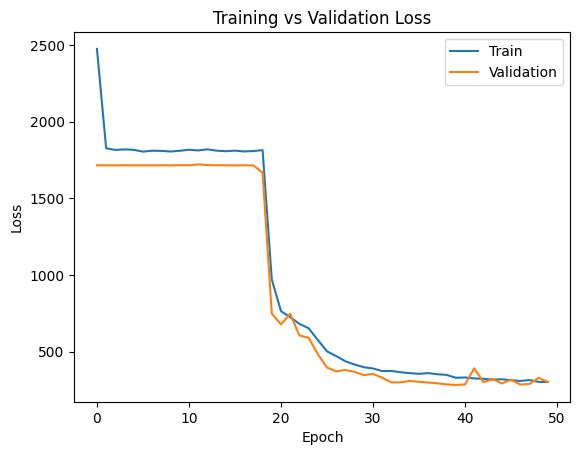

In [75]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()
